# Spatial Variation in UK Road Traffic Collisions

**Student ID:** 2514289  
**Module:** CASA0006 Data Science for Spatial Systems  
**Dataset:** UK Road Safety Data  
**GitHub repository:** https://github.com/zczqcx5/CASA0006_dataset

## Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Table of contents

- [Introduction](#Introduction)
- [Research questions](#Research-questions)
- [Data](#Data)
- [Methodology](#Methodology)
- [Results and discussion](#Results-and-discussion)
- [Conclusion](#Conclusion)
- [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Road traffic collisions are an important transport, public health, and spatial planning issue. Globally, road traffic injuries cause around 1.19 million deaths each year, which means that road safety remains a major policy challenge rather than a marginal transport problem. In Great Britain, police-reported personal-injury collisions are recorded through the STATS19 system, making the UK road safety open data an appropriate source for analysing where collisions occur, under what conditions they occur, and how they vary across places.

Previous research suggests that weather conditions can shape road collision patterns. **Edwards (1998)** examined the relationship between recorded weather and road accident severity, showing that severity patterns differed across weather conditions rather than remaining constant in all environments. **Edwards (1999)** further explored the temporal distribution of road accidents in adverse weather, highlighting that weather-related collision risk is not only environmental but also time-sensitive. Together, these studies show that weather should not be treated as a simple background condition in road safety analysis. 

Road safety outcomes are also unevenly distributed across space. **Jones et al. (2008)** analysed local authority districts in England and Wales and found substantial geographical variation in fatalities and injuries, with district-level contextual factors helping to explain these differences. This suggests that collision patterns are spatially concentrated rather than evenly distributed, and that area-level analysis is important for understanding local road safety burdens.

Building on these three studies, this project uses the 2024 UK road safety collision dataset to examine how recorded collisions vary across environmental and spatial contexts. In particular, it focuses on weather conditions, road surface conditions, collision severity, and area-level variation. By combining descriptive analysis, cross-tabulation, and spatial aggregation, the project aims to provide a clear overview of how collisions are distributed in the 2024 dataset and what these patterns suggest for road safety analysis in the UK.

## Research questions

[[ go back to the top ]](#Table-of-contents)

The main research question of this project is:

**How do road traffic collisions vary across environmental and spatial contexts in the UK?**

This question is explored through the following sub-questions:

1. **How are recorded collisions distributed across weather and road surface conditions?**
2. **To what extent does collision severity differ across environmental conditions?**
3. **How unevenly are collisions distributed across local authority areas in the 2024 dataset?**

## Data

[[ go back to the top ]](#Table-of-contents)

### 3.1 Main dataset

The main dataset used in this project is the **2024 UK Road Safety Collision Dataset** from the UK Road Safety Open Data portal. This dataset records reported road traffic collisions involving personal injury and includes information on location, severity, time, weather conditions, road surface conditions, and administrative area codes.

The dataset is suitable for this project because it provides both spatial information and contextual variables, making it possible to examine how collisions vary across environmental and area-based contexts.

In [2]:
file_path = "https://raw.githubusercontent.com/zczqcx5/CASA0006_dataset/main/data/dft-road-casualty-statistics-collision-2024.csv"
df = pd.read_csv(file_path, low_memory=False)


### 3.2 Initial inspection

The dataset was first inspected using basic functions such as `.shape`, `.columns`, `.info()`, and `.head()` in order to understand its size, structure, variable names, and missing values.

The dataset contains **100,927 collision records** and **44 variables**. Initial inspection showed that missing values were very limited in most of the variables used in this analysis.

In [3]:
df.shape

(100927, 44)

In [4]:
df.columns.tolist()

['collision_index',
 'collision_year',
 'collision_ref_no',
 'location_easting_osgr',
 'location_northing_osgr',
 'longitude',
 'latitude',
 'police_force',
 'collision_severity',
 'number_of_vehicles',
 'number_of_casualties',
 'date',
 'day_of_week',
 'time',
 'local_authority_district',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'first_road_class',
 'first_road_number',
 'road_type',
 'speed_limit',
 'junction_detail_historic',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'pedestrian_crossing',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards_historic',
 'carriageway_hazards',
 'urban_or_rural_area',
 'did_police_officer_attend_scene_of_accident',
 'trunk_road_flag',
 'lsoa_of_accident_location',
 'enhanced_severit

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100927 entries, 0 to 100926
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   100927 non-null  str    
 1   collision_year                                    100927 non-null  int64  
 2   collision_ref_no                                  100927 non-null  str    
 3   location_easting_osgr                             100927 non-null  int64  
 4   location_northing_osgr                            100927 non-null  int64  
 5   longitude                                         100927 non-null  float64
 6   latitude                                          100927 non-null  float64
 7   police_force                                      100927 non-null  int64  
 8   collision_severity                                100927 non-null  int64  
 9   number_of_vehic

In [6]:
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202417M119024,2024,17M119024,450057,519938,-1.22722,54.57219,17,3,2,...,-1,0,1,3,2,E01035190,3,1,0.000000,1.000000
1,202417S312124,2024,17S312124,445858,516830,-1.29265,54.54466,17,3,1,...,-1,0,1,3,2,E01012239,3,1,0.000000,1.000000
2,2024070110901,2024,070110901,364765,390979,-2.53157,53.41443,7,3,2,...,0,0,2,2,2,E01012459,-1,0,0.014743,0.985257
3,2024041446676,2024,041446676,365989,419804,-2.51630,53.67359,4,2,1,...,-1,0,2,1,2,E01012628,6,1,1.000000,0.000000
4,2024041478641,2024,041478641,366864,430071,-2.50416,53.76592,4,2,2,...,-1,0,1,1,2,E01012581,7,1,1.000000,0.000000


In [7]:
df.isna().sum().sort_values(ascending=False).head(20)

local_authority_highway_current    3
collision_index                    0
collision_ref_no                   0
collision_year                     0
location_northing_osgr             0
longitude                          0
latitude                           0
police_force                       0
collision_severity                 0
number_of_vehicles                 0
number_of_casualties               0
location_easting_osgr              0
date                               0
day_of_week                        0
local_authority_district           0
time                               0
local_authority_ons_district       0
local_authority_highway            0
first_road_class                   0
first_road_number                  0
dtype: int64

### 3.3 Variable selection

To keep the analysis focused on the research question, only variables directly related to spatial location, collision outcome, environmental conditions, and area identifiers were retained for further analysis.

The selected variables included:

- `longitude`
- `latitude`
- `collision_severity`
- `number_of_vehicles`
- `number_of_casualties`
- `date`
- `day_of_week`
- `time`
- `local_authority_ons_district`
- `road_type`
- `speed_limit`
- `junction_detail`
- `junction_control`
- `light_conditions`
- `weather_conditions`
- `road_surface_conditions`
- `special_conditions_at_site`
- `carriageway_hazards`
- `urban_or_rural_area`
- `lsoa_of_accident_location`

A smaller working dataset was then created for the analysis.

In [8]:
selected_cols = [
    "collision_index",                 
    "collision_year",
    "longitude",
    "latitude",
    "collision_severity",
    "number_of_vehicles",
    "number_of_casualties",
    "date",
    "day_of_week",
    "time",
    "local_authority_district",
    "local_authority_ons_district",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "lsoa_of_accident_location"
]

df_selected = df[selected_cols].copy()
df_selected.head()

,collision_index,collision_year,longitude,latitude,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,...,speed_limit,junction_detail,junction_control,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,lsoa_of_accident_location
0,202417M119024,2024,-1.22722,54.57219,3,2,1,05/12/2024,5,16:10,...,30,0,-1,4,2,2,-1,0,1,E01035190
1,202417S312124,2024,-1.29265,54.54466,3,1,1,22/10/2024,3,14:56,...,30,0,-1,1,1,1,-1,0,1,E01012239
2,2024070110901,2024,-2.53157,53.41443,3,2,1,24/01/2024,4,17:50,...,30,13,4,4,1,1,0,0,2,E01012459
3,2024041446676,2024,-2.51630,53.67359,2,1,1,22/05/2024,4,17:45,...,50,0,-1,1,5,5,-1,0,2,E01012628
4,2024041478641,2024,-2.50416,53.76592,2,2,1,11/08/2024,1,15:36,...,50,16,4,1,1,1,-1,0,1,E01012581


In [9]:
df_selected.shape

(100927, 23)


### 3.4 Data cleaning

Several preprocessing steps were carried out before analysis.

First, the `date` variable was converted into datetime format. Second, key coded variables were converted into categorical format where appropriate in order to improve readability and reduce memory usage. Third, the official 2024 code list was used to translate coded variables into readable labels for interpretation and visualisation.

In particular, readable labels were created for:

- collision severity
- weather conditions
- road surface conditions
- light conditions


In [10]:
df_clean = df_selected.copy()

df_clean["date"] = pd.to_datetime(df_clean["date"], dayfirst=True, errors="coerce")

df_clean["time"] = df_clean["time"].astype(str)

cat_cols = [
    "collision_severity",
    "day_of_week",
    "local_authority_district",
    "local_authority_ons_district",
    "road_type",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "lsoa_of_accident_location"
]

for col in cat_cols:
    df_clean[col] = df_clean[col].astype("category")

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 100927 entries, 0 to 100926
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   collision_index               100927 non-null  str           
 1   collision_year                100927 non-null  int64         
 2   longitude                     100927 non-null  float64       
 3   latitude                      100927 non-null  float64       
 4   collision_severity            100927 non-null  category      
 5   number_of_vehicles            100927 non-null  int64         
 6   number_of_casualties          100927 non-null  int64         
 7   date                          100927 non-null  datetime64[us]
 8   day_of_week                   100927 non-null  category      
 9   time                          100927 non-null  str           
 10  local_authority_district      100927 non-null  category      
 11  local_authority_ons_dist

### 3.5 Key variables used in the analysis

| Variable | Description | Role in analysis |
|---|---|---|
| collision_severity | Severity of collision | Outcome variable |
| weather_conditions | Weather at time of collision | Environmental condition |
| road_surface_conditions | Road surface condition | Environmental condition |
| light_conditions | Light condition | Environmental condition |
| longitude / latitude | Coordinates of collision | Spatial location |
| local_authority_ons_district | ONS district code | Area-level aggregation |
| number_of_casualties | Number of casualties | Collision context |
| number_of_vehicles | Number of vehicles involved | Collision context |
| date / day_of_week / time | Temporal information | Temporal context |

### 3.6 Load the official code list

The official 2024 code list was loaded from the accompanying data guide. This was used to translate coded variables into human-readable labels for analysis and visualisation.

In [11]:
guide_path = "https://raw.githubusercontent.com/zczqcx5/CASA0006_dataset/main/data/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx"
guide_sheets = pd.ExcelFile(guide_path)
codebook = pd.read_excel(guide_path, sheet_name="2024_code_list")

In [12]:
for sheet in guide_sheets.sheet_names:
    print(sheet)

2024_code_list


In [13]:
codebook = pd.read_excel(guide_path, sheet_name="2024_code_list")
codebook.head(20)

,table,field name,code/format,label,note
0,collision,collision_index,NaN,NaN,unique value for each collision. The collision...
1,collision,collision_year,NaN,NaN,NaN
2,collision,collision_ref_no,NaN,NaN,In year id used by the police to reference a c...
3,collision,location_easting_osgr,NaN,NaN,Null if not known
4,collision,location_northing_osgr,NaN,NaN,Null if not known
5,collision,longitude,NaN,NaN,Null if not known
6,collision,latitude,NaN,NaN,Null if not known
7,collision,police_force,1,Metropolitan Police,NaN
8,collision,police_force,3,Cumbria,NaN
9,collision,police_force,4,Lancashire,NaN


In [14]:
codebook.columns.tolist()
codebook.shape

(1820, 5)

In [15]:
target_vars = [
    "collision_severity",
    "weather_conditions",
    "road_surface_conditions",
    "light_conditions",
    "road_type",
    "urban_or_rural_area"
]

for var in target_vars:
    print(f"\n===== {var} =====")
    display(codebook[codebook.astype(str).apply(lambda row: row.str.contains(var, case=False, na=False)).any(axis=1)].head(20))


===== collision_severity =====


,table,field name,code/format,label,note
59,collision,collision_severity,1,Fatal,NaN
60,collision,collision_severity,2,Serious,NaN
61,collision,collision_severity,3,Slight,NaN
62,collision,enhanced_collision_severity,1,Fatal,category introduced where collected in 2023
63,collision,enhanced_collision_severity,5,Very Serious,category introduced where collected in 2023
64,collision,enhanced_collision_severity,6,Moderately Serious,category introduced where collected in 2023
65,collision,enhanced_collision_severity,7,Less Serious,category introduced where collected in 2023
66,collision,enhanced_collision_severity,3,Slight,category introduced where collected in 2023
67,collision,enhanced_collision_severity,-1,Data missing or out of range,category introduced where collected in 2023



===== weather_conditions =====


,table,field name,code/format,label,note
1343,collision,weather_conditions,1,Fine no high winds,NaN
1344,collision,weather_conditions,2,Raining no high winds,NaN
1345,collision,weather_conditions,3,Snowing no high winds,NaN
1346,collision,weather_conditions,4,Fine + high winds,NaN
1347,collision,weather_conditions,5,Raining + high winds,NaN
1348,collision,weather_conditions,6,Snowing + high winds,NaN
1349,collision,weather_conditions,7,Fog or mist,NaN
1350,collision,weather_conditions,8,Other,NaN
1351,collision,weather_conditions,9,Unknown,NaN
1352,collision,weather_conditions,-1,Data missing or out of range,NaN



===== road_surface_conditions =====


...

,table,field name,code/format,label,note
1337,collision,light_conditions,1,Daylight,NaN
1338,collision,light_conditions,4,Darkness - lights lit,NaN
1339,collision,light_conditions,5,Darkness - lights unlit,NaN
1340,collision,light_conditions,6,Darkness - no lighting,NaN
1341,collision,light_conditions,7,Darkness - lighting unknown,NaN
1342,collision,light_conditions,-1,Data missing or out of range,NaN



===== road_type =====


,table,field name,code/format,label,note
1266,collision,road_type,1,Roundabout,NaN
1267,collision,road_type,2,One way street,NaN
1268,collision,road_type,3,Dual carriageway,NaN
1269,collision,road_type,6,Single carriageway,NaN
1270,collision,road_type,7,Slip road,NaN
1271,collision,road_type,9,Unknown,NaN
1272,collision,road_type,12,One way street/Slip road,NaN
1273,collision,road_type,-1,Data missing or out of range,NaN



===== urban_or_rural_area =====


,table,field name,code/format,label,note
1396,collision,urban_or_rural_area,1,Urban,field introduced in 1994
1397,collision,urban_or_rural_area,2,Rural,field introduced in 1994
1398,collision,urban_or_rural_area,3,Unallocated,field introduced in 1994
1399,collision,urban_or_rural_area,-1,Data missing or out of range,field introduced in 1994


### 3.7 Translate coded variables

Several key variables in the dataset were recorded as numeric codes rather than readable text. To improve interpretability, the official code list was used to create label mappings for collision severity, weather conditions, road surface conditions, and light conditions.

In [16]:
def make_map(var):
    t = codebook[codebook["field name"] == var][["code/format", "label"]].dropna()
    t["code/format"] = pd.to_numeric(t["code/format"], errors="coerce")
    t = t.dropna()
    t["code/format"] = t["code/format"].astype(int)
    return dict(zip(t["code/format"], t["label"]))

In [17]:
severity_map = make_map("collision_severity")
weather_map = make_map("weather_conditions")
surface_map = make_map("road_surface_conditions")
light_map = make_map("light_conditions")

### 3.8 Create readable label columns

Readable label columns were added to the working dataset so that the subsequent analysis could use meaningful category names instead of numeric codes.

In [18]:
df_clean["severity_label"] = df_clean["collision_severity"].astype(int).map(severity_map)
df_clean["weather_label"] = df_clean["weather_conditions"].astype(int).map(weather_map)
df_clean["surface_label"] = df_clean["road_surface_conditions"].astype(int).map(surface_map)
df_clean["light_label"] = df_clean["light_conditions"].astype(int).map(light_map)

df_clean[["collision_severity","severity_label","weather_conditions","weather_label"]].head()

,collision_severity,severity_label,weather_conditions,weather_label
0,3,Slight,2,Raining no high winds
1,3,Slight,1,Fine no high winds
2,3,Slight,1,Fine no high winds
3,2,Serious,5,Raining + high winds
4,2,Serious,1,Fine no high winds


In [19]:
df_clean[["severity_label","weather_label","surface_label","light_label"]].isna().sum()

severity_label    0
weather_label     0
surface_label     0
light_label       0
dtype: int64

### 3.9 Data limitations

One limitation of the 2024 dataset is that the legacy `local_authority_district` field was not informative in this analysis, as it only contained the value `-1`. Therefore, the spatial aggregation in this project relied on `local_authority_ons_district` instead.

In addition, the current analysis is based on recorded collision counts rather than standardised rates, which means that differences in population, traffic flow, and road network size are not yet taken into account.

## Methodology

[[ go back to the top ]](#Table-of-contents)

### 4.1 Data preparation

The analysis was based on the 2024 UK road safety collision dataset. A reduced set of variables was selected to match the research question, focusing on spatial location, collision severity, weather conditions, road surface conditions, and area identifiers. In addition, the `date` field was converted into datetime format, and key coded variables were translated into readable labels using the official 2024 code list.

### 4.2 Descriptive analysis

Descriptive statistics were used to summarise the overall distribution of collisions across environmental conditions. In particular, frequency counts and percentage distributions were calculated for weather conditions and road surface conditions. This step provided an initial overview of the conditions under which collisions were most commonly recorded.

### 4.3 Cross-tabulation of severity and conditions

Cross-tabulation was used to compare collision severity across environmental categories. The analysis examined how the distribution of slight, serious, and fatal collisions varied across weather conditions and road surface conditions. Percentage-based cross-tabulations were used so that comparisons could be made more clearly across categories of different sizes.

### 4.4 Spatial aggregation

To examine spatial variation, collisions were aggregated by local authority area using ONS district codes. Area-level collision counts were then compared in order to identify districts with relatively high numbers of recorded collisions. This made it possible to assess whether collisions were evenly distributed across space or concentrated in particular areas.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### 5.1 Descriptive patterns of collision conditions

This section summarises the distribution of collisions across different weather and road surface conditions. These descriptive results provide an initial overview of the environmental contexts in which collisions occurred in 2024.

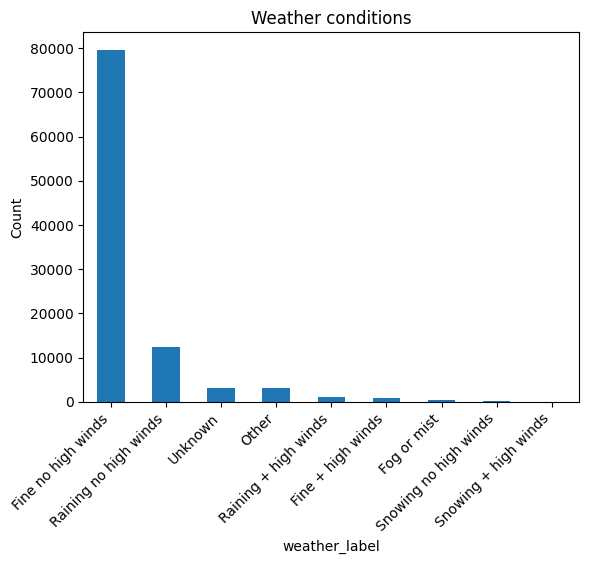

In [20]:
df_clean["weather_label"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Weather conditions")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

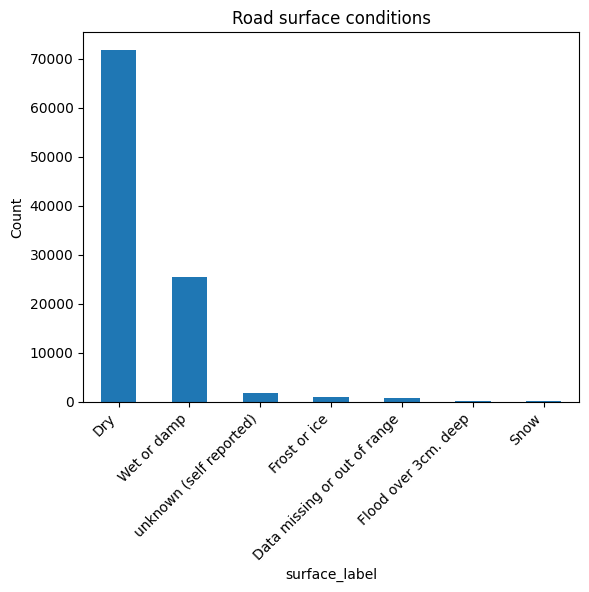

In [21]:
df_clean["surface_label"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Road surface conditions")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

### 5.2 Collision severity across environmental conditions

This section examines whether collision severity differs across weather and road surface conditions. The aim is to move beyond simple counts and explore whether some environmental contexts are associated with more serious collisions.

In [22]:
weather_severity = pd.crosstab(df_clean["weather_label"], df_clean["severity_label"])
weather_severity

severity_label,Fatal,Serious,Slight
weather_label,,,
Fine + high winds,23,257,655
Fine no high winds,1225,18996,59380
Fog or mist,8,132,334
Other,24,655,2373
Raining + high winds,36,282,807
Raining no high winds,173,2840,9315
Snowing + high winds,0,7,18
Snowing no high winds,2,59,181
Unknown,11,339,2795


In [23]:
surface_severity = pd.crosstab(df_clean["surface_label"], df_clean["severity_label"])
surface_severity

severity_label,Fatal,Serious,Slight
surface_label,,,
Data missing or out of range,1,73,630
Dry,1042,16956,53834
Flood over 3cm. deep,5,42,145
Frost or ice,8,251,756
Snow,1,38,120
Wet or damp,444,6105,18806
unknown (self reported),1,102,1567


In [24]:
weather_severity_pct = pd.crosstab(
    df_clean["weather_label"],
    df_clean["severity_label"],
    normalize="index"
).round(3) * 100

weather_severity_pct

severity_label,Fatal,Serious,Slight
weather_label,,,
Fine + high winds,2.5,27.5,70.1
Fine no high winds,1.5,23.9,74.6
Fog or mist,1.7,27.8,70.5
Other,0.8,21.5,77.8
Raining + high winds,3.2,25.1,71.7
Raining no high winds,1.4,23.0,75.6
Snowing + high winds,0.0,28.0,72.0
Snowing no high winds,0.8,24.4,74.8
Unknown,0.3,10.8,88.9


In [25]:
surface_severity_pct = pd.crosstab(
    df_clean["surface_label"],
    df_clean["severity_label"],
    normalize="index"
).round(3) * 100

surface_severity_pct

severity_label,Fatal,Serious,Slight
surface_label,,,
Data missing or out of range,0.1,10.4,89.5
Dry,1.5,23.6,74.9
Flood over 3cm. deep,2.6,21.9,75.5
Frost or ice,0.8,24.7,74.5
Snow,0.6,23.9,75.5
Wet or damp,1.8,24.1,74.2
unknown (self reported),0.1,6.1,93.8


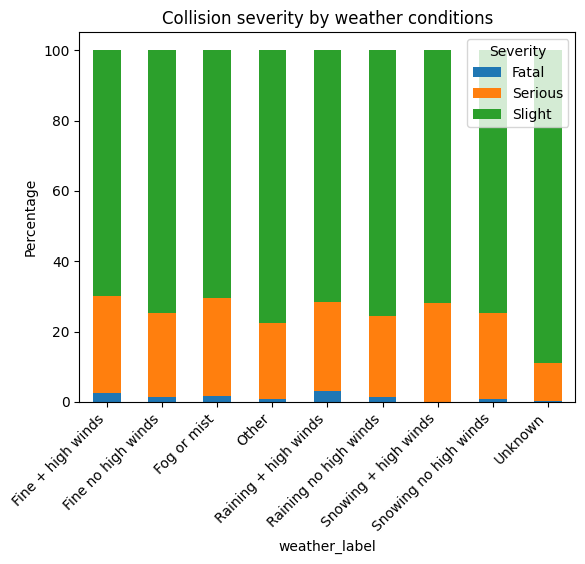

In [26]:
weather_severity_pct.plot(kind="bar", stacked=True)
plt.title("Collision severity by weather conditions")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Severity")
plt.show()

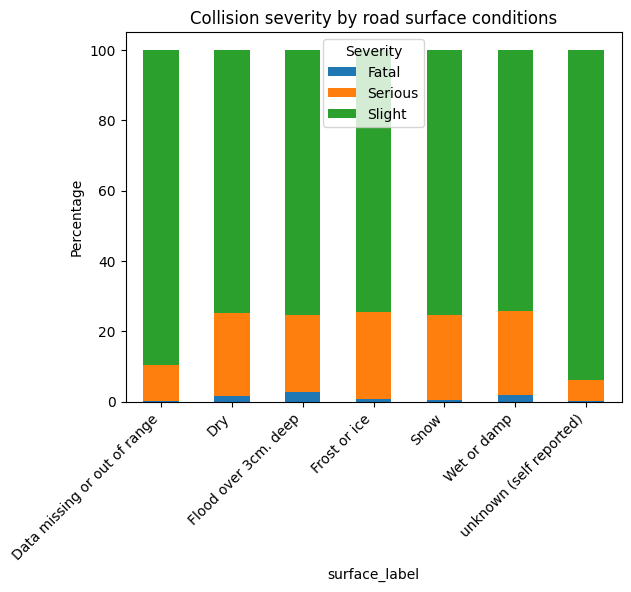

In [27]:
surface_severity_pct.plot(kind="bar", stacked=True)
plt.title("Collision severity by road surface conditions")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Severity")
plt.show()

The cross-tabulations show that slight collisions account for the largest share across all weather and road surface categories. However, the percentage distribution of serious and fatal collisions varies slightly between conditions. This suggests that environmental context may be associated with differences in collision severity, although these patterns should be interpreted with caution because the analysis is descriptive rather than causal.

### 5.3 Spatial distribution of collisions

This section explores the spatial distribution of collisions across local authority areas using ONS district codes. The results show clear variation in collision counts across areas, with a small number of districts recording substantially higher counts than others in 2024.

In [28]:
area_counts = df_clean["local_authority_ons_district"].value_counts().reset_index()
area_counts.columns = ["local_authority_ons_district", "collision_count"]
area_counts.head(10)

,local_authority_ons_district,collision_count
0,E08000025,2296
1,E08000035,1463
2,E09000033,1094
3,E06000065,1043
4,E08000032,1030
5,E06000052,941
6,E09000008,933
7,E09000010,922
8,E09000030,901
9,E06000054,880


In [29]:
codebook[codebook["field name"] == "local_authority_ons_district"].head(20)

,table,field name,code/format,label,note
612,collision,local_authority_ons_district,E06000001,Hartlepool,NaN
613,collision,local_authority_ons_district,E06000002,Middlesbrough,NaN
614,collision,local_authority_ons_district,E06000003,Redcar and Cleveland,NaN
615,collision,local_authority_ons_district,E06000004,Stockton-on-Tees,NaN
616,collision,local_authority_ons_district,E06000005,Darlington,NaN
617,collision,local_authority_ons_district,E06000006,Halton,NaN
618,collision,local_authority_ons_district,E06000007,Warrington,NaN
619,collision,local_authority_ons_district,E06000008,Blackburn with Darwen,NaN
620,collision,local_authority_ons_district,E06000009,Blackpool,NaN
621,collision,local_authority_ons_district,E06000010,"Kingston upon Hull, City of",NaN


In [30]:
ons_map_df = codebook[codebook["field name"] == "local_authority_ons_district"][["code/format", "label"]].dropna()
ons_map = dict(zip(ons_map_df["code/format"], ons_map_df["label"]))

In [31]:
area_counts["area_name"] = area_counts["local_authority_ons_district"].map(ons_map)
area_counts.head(10)

,local_authority_ons_district,collision_count,area_name
0,E08000025,2296,Birmingham
1,E08000035,1463,Leeds
2,E09000033,1094,Westminster
3,E06000065,1043,North Yorkshire
4,E08000032,1030,Bradford
5,E06000052,941,Cornwall
6,E09000008,933,Croydon
7,E09000010,922,Enfield
8,E09000030,901,Tower Hamlets
9,E06000054,880,Wiltshire


In [32]:
top10_areas = area_counts.head(10)
top10_areas[["area_name", "collision_count"]]

,area_name,collision_count
0,Birmingham,2296
1,Leeds,1463
2,Westminster,1094
3,North Yorkshire,1043
4,Bradford,1030
5,Cornwall,941
6,Croydon,933
7,Enfield,922
8,Tower Hamlets,901
9,Wiltshire,880


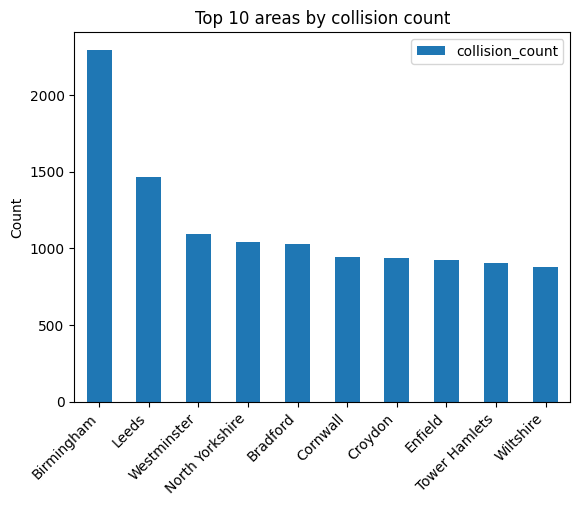

In [33]:
top10_areas.plot(
    x="area_name",
    y="collision_count",
    kind="bar"
)
plt.title("Top 10 areas by collision count")
plt.ylabel("Count")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.show()

The top 10 area summary shows that collision counts are not evenly distributed across space. Instead, a relatively small number of local authority areas account for a disproportionately large share of recorded collisions in the 2024 dataset.

It is important to note that these area-level results are based on collision counts rather than standardised rates. They therefore show the distribution of recorded collision burden, but not directly the relative level of collision risk.

These area-level results should therefore be interpreted as the distribution of recorded collision burden rather than direct evidence of relative collision risk.

### 5.4 Discussion of main findings

The results show that most recorded collisions occurred in fine weather and on dry road surfaces, although this likely reflects common travel conditions as well as collision risk. Slight collisions accounted for the majority of cases across environmental categories, but the shares of serious and fatal collisions varied somewhat across conditions.

The spatial analysis also showed that collisions were unevenly distributed across local authority areas, with a relatively small number of districts recording much higher counts than others. This suggests that collision burden is spatially concentrated rather than evenly distributed.

However, these findings should be interpreted with caution. The analysis is descriptive rather than causal, and the spatial comparison is based on collision counts rather than standardised rates. This means that differences in population, traffic volume, road network extent, and travel exposure are not taken into account.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This project examined how road traffic collisions varied across environmental and spatial contexts in the UK using the 2024 road safety collision dataset.

The results show that most recorded collisions occurred in fine weather and on dry road surfaces, while slight collisions accounted for the majority of cases across major environmental categories. Collision counts were also unevenly distributed across local authority areas, indicating clear spatial concentration.

Overall, the findings suggest that road traffic collisions vary across both environmental and spatial contexts. However, the analysis is based on collision counts rather than standardised rates, so higher counts should not be interpreted directly as higher relative risk. Future work should therefore use rate-based measures and incorporate additional exposure variables, such as population, traffic flow, or road network characteristics, in order to produce a more robust assessment of relative collision risk.

## References

[[ go back to the top ]](#Table-of-contents)

Edwards, J.B. (1998) ‘The relationship between road accident severity and recorded weather’, Journal of Safety Research, 29(4), pp. 249–262.

Edwards, J.B. (1999) ‘The temporal distribution of road accidents in adverse weather’, Meteorological Applications, 6(1), pp. 59–68.

Jones, A.P., Haynes, R., Kennedy, V. and Harvey, I. (2008) ‘Geographical variations in mortality and morbidity from road traffic accidents in England and Wales’, Health & Place, 14(3), pp. 519–535.

UK Department for Transport (2025) Road safety open data. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data
 (Accessed: 23 April 2026).

World Health Organization (2023) Road traffic injuries. Available at: https://www.who.int/news-room/fact-sheets/detail/road-traffic-injuries
 (Accessed: 23 April 2026).